# Cliff Walking: TD Animation

This notebook animates how state values change while Sarsa and Q-learning learn the cliff walking task.

## Installation and Setup

In [1]:
# uncomment if needed
# %pip install "gym-classics2 @ git+https://github.com/mhahsler/gym-classics2.git"

In [2]:
import numpy as np
np.set_printoptions(precision=2)

SEED = 42
rng = np.random.default_rng(SEED)

In [3]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

from gym_classics2.animation import gridworld_animate                               
from gym_classics2.algorithms.policy import random_policy

/home/mhahsler/miniconda3/envs/reinforcement-learning/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cliff Walking

Example from Sutton/Barto Chapter 6.

![Clif Walking problem description](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-intro_Cliffwalking.png)

Cliff Walking is a standard undiscounted,
episodic task, with start
and goal states, and the usual actions
causing movement up, down,
right, and left. Reward is −1 on all
transitions except those into the region
marked “The Cliff.” Stepping
into this region incurs a reward of
−100 and sends the agent instantly
back to the start.

In [4]:
gym_env = gym.make('CliffWalk-v1', tabular = True)
env = gym_env.unwrapped
env.reset(seed=SEED)

(0, {})

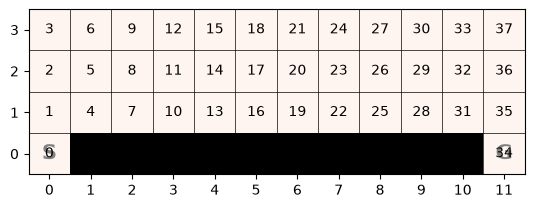

In [5]:
env.image()

## Comparison

In [6]:
from gym_classics2.algorithms.temporal_difference_learning import Sarsa_0, Q_learning
from gym_classics2.algorithms.policy import greedy_policy
from gym_classics2.animation import gridworld_animate
from gym_classics2.performance import plot_episode_lengths, plot_returns

Sarsa: 100%|██████████| 100/100 [00:00<00:00, 433.27it/s]


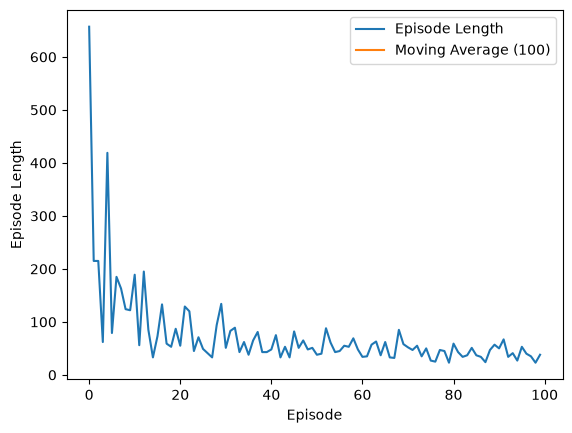

In [7]:
Q, history = Sarsa_0(env, discount=1, alpha=0.1, epsilon=0.1, n=100, history = True,rng=rng)
plot_episode_lengths(history["ep_lens"])

Vs = [Q.max(axis=1) for Q in history["Qs"]]
gridworld_animate(env, Vs)

Q-Learning: 100%|██████████| 100/100 [00:00<00:00, 444.08it/s]


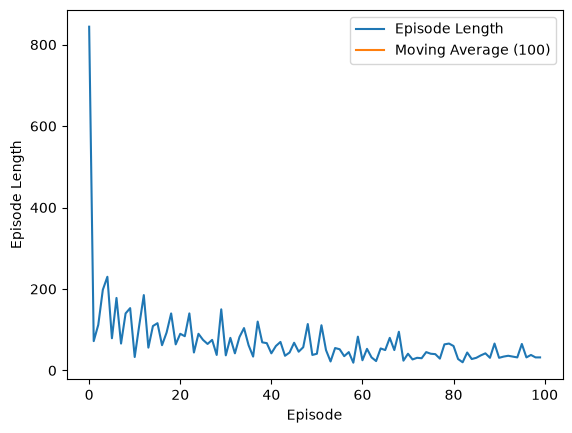

In [8]:
Q, history = Q_learning(env, discount=1, alpha=0.1, epsilon=0.1, n=100, history = True,rng=rng)
plot_episode_lengths(history["ep_lens"])

Vs = [Q.max(axis=1) for Q in history["Qs"]]
gridworld_animate(env, Vs)


&copy; 2025 [Michael Hahsler](https://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)